# Notebook 3 — Google Trends Data 

### Business Context
Economic indicators tell us how large a country's economy is and how it is growing. But they cannot tell us whether people in that country are actually interested in travel right now. Google Trends fills this gap.

### Purpose of This Notebook
This notebook builds the full Google Trends data pipeline:
- Retrieve Google Trends data for travel related keywords.
- Evaluate which keyword can best serve as a proxy for travel demand.

In [16]:
# Importing libraries and packages

import pandas as pd
from pytrends.request import TrendReq

# Create Google Trends Connection

PyTrends is used to access Google Trends data programmatically.
Search interest data is collected across geographic locations and used as a proxy for travel demand.

In [17]:
# Create Google Trends connection

pytrends = TrendReq(
    hl="en-US",
    tz=360
)

## Candidate Keywords

The candidate keywords were selected during the project planning phase and will be evaluated to determine which keyword provides the most meaningful proxy for travel demand.
Selected candidate keywords:
- travel
- vacation
- holiday
- hotels
- flights

In [18]:
# define candidate keywords

keywords = [
    "travel",
    "vacation",
    "holiday",
    "hotels",
    "flights"
]

keywords

['travel', 'vacation', 'holiday', 'hotels', 'flights']

# Retrieve GT Data

- Google Trends data is retrieved for each candidate keyword separately
- The data is collected at the geographic level to allow comparison of search interest across locations
- To avoid rate limiting a short pause is added between API requests

In [19]:
# import package for request pauses

import time

In [20]:
# retrieve Google Trends data for each keyword last 12 mnths

all_keywords = []

for keyword in keywords:

    print(f"getting data for: {keyword}")

    pytrends.build_payload(
        kw_list=[keyword],
        timeframe="today 12-m"
    )

    df = pytrends.interest_by_region(
        resolution="COUNTRY",
        inc_low_vol=True,
        inc_geo_code=False
    )

    df = df.reset_index()
    df["keyword"] = keyword

    all_keywords.append(df)

    time.sleep(5)

trends_keywords_df = pd.concat(
    all_keywords,
    ignore_index=True
)

trends_keywords_df.head()

getting data for: travel
getting data for: vacation
getting data for: holiday
getting data for: hotels
getting data for: flights


,geoName,travel,keyword,vacation,holiday,hotels,flights
0,Afghanistan,9.0,travel,NaN,NaN,NaN,NaN
1,Albania,45.0,travel,NaN,NaN,NaN,NaN
2,Algeria,11.0,travel,NaN,NaN,NaN,NaN
3,American Samoa,81.0,travel,NaN,NaN,NaN,NaN
4,Andorra,23.0,travel,NaN,NaN,NaN,NaN


## Combinee raw dataset

- Each keyword was retrieved separately and combined into a single dataframe.
- Because GT returns one keyword per API request, the dataset currently contains one keyword per row. This structure (returning Nan) is not suitable for keyword comparison and will be reshaped in a later step.

In [6]:
# save raw GT dataset before inspection and transformation

trends_keywords_df.to_csv(
    "google_trends_raw_20260620.csv",
    index=False
)

In [21]:
# AZ TROUBLESHOOTING 24/06

# First loading saved raw GT dataset - this avoids rerunning the PyTrends API 

import pandas as pd

trends_keywords_df = pd.read_csv("google_trends_raw_20260620.csv")

trends_keywords_df.head()

,geoName,travel,keyword,vacation,holiday,hotels,flights
0,Afghanistan,9.0,travel,NaN,NaN,NaN,NaN
1,Albania,42.0,travel,NaN,NaN,NaN,NaN
2,Algeria,9.0,travel,NaN,NaN,NaN,NaN
3,American Samoa,74.0,travel,NaN,NaN,NaN,NaN
4,Andorra,22.0,travel,NaN,NaN,NaN,NaN


# Data inspection

Before restructuring the data, I inspect the dataset to understand its shape, columns, data types, missing values, duplicate rows and keyword coverage.

In [22]:
# check dataset dimensions

trends_keywords_df.shape

(1250, 7)

In [23]:
# inspect column names

trends_keywords_df.columns

Index(['geoName', 'travel', 'keyword', 'vacation', 'holiday', 'hotels',
       'flights'],
      dtype='object')

In [24]:
# inspect dtypes

trends_keywords_df.dtypes

geoName      object
travel      float64
keyword      object
vacation    float64
holiday     float64
hotels      float64
flights     float64
dtype: object

In [25]:
# check missing values by column

trends_keywords_df.isnull().sum()

geoName        0
travel      1000
keyword        0
vacation    1000
holiday     1000
hotels      1000
flights     1000
dtype: int64

In [26]:
# check duplicate rows

trends_keywords_df.duplicated().sum()

0

In [27]:
# check keyword coverage

trends_keywords_df["keyword"].value_counts()

travel      250
vacation    250
holiday     250
hotels      250
flights     250
Name: keyword, dtype: int64

In [28]:
# inspect sample records

trends_keywords_df.head(10)

,geoName,travel,keyword,vacation,holiday,hotels,flights
0,Afghanistan,9.0,travel,NaN,NaN,NaN,NaN
1,Albania,42.0,travel,NaN,NaN,NaN,NaN
2,Algeria,9.0,travel,NaN,NaN,NaN,NaN
3,American Samoa,74.0,travel,NaN,NaN,NaN,NaN
4,Andorra,22.0,travel,NaN,NaN,NaN,NaN
5,Angola,5.0,travel,NaN,NaN,NaN,NaN
6,Anguilla,58.0,travel,NaN,NaN,NaN,NaN
7,Antarctica,0.0,travel,NaN,NaN,NaN,NaN
8,Antigua & Barbuda,46.0,travel,NaN,NaN,NaN,NaN
9,Argentina,8.0,travel,NaN,NaN,NaN,NaN


### Initial Findings — Data Inspection

- The dataset contains 1,250 rows and 7 columns.
- Five candidate keywords were retrieved from Google Trends.
- Each keyword returned 250 geographic locations.
- No duplicate rows were identified.
- Search interest values are stored as numeric variables.
- Missing values exist in keyword-specific score columns because the data is currently in wide format — each keyword is stored in a separate column rather than a single score column.

# Data restructuring

The combined raw dataset stores GT scores across multiple keyword columns. To enable keyword-level analysis, the dataset is reshaped into a long format containing:

- geoName
- keyword
- trend_score

The five keyword-specific columns (travel, vacation, holiday, hotels and flights) are converted into a single categorical **keyword** column with its corresponding trend_score. 
Rows containing missing trend scores are removed, resulting in one observation per location & keyword combination.

This structure allows search interest scores to be compared consistently across locations & keywords.

In [38]:
# Reshape dataset into long format

# The original 'keyword' column only identifies which API request created each row
# We reshape the five keyword score columns and keep only valid trend scores

trends_long_df = trends_keywords_df.melt(
    id_vars=["geoName"],
    value_vars=["travel", "vacation", "holiday", "hotels", "flights"],
    var_name="keyword",
    value_name="trend_score"
)

trends_long_df = trends_long_df.dropna(subset=["trend_score"])

trends_long_df.head()

,geoName,keyword,trend_score
0,Afghanistan,travel,9.0
1,Albania,travel,42.0
2,Algeria,travel,9.0
3,American Samoa,travel,74.0
4,Andorra,travel,22.0


In [39]:
# Check dataset dimensions after reshaping

print(trends_long_df.shape)
trends_long_df["keyword"].value_counts()

(1250, 3)


travel      250
vacation    250
holiday     250
hotels      250
flights     250
Name: keyword, dtype: int64

In [40]:
# inspect sample records after reshaping

trends_long_df.head(10)

,geoName,keyword,trend_score
0,Afghanistan,travel,9.0
1,Albania,travel,42.0
2,Algeria,travel,9.0
3,American Samoa,travel,74.0
4,Andorra,travel,22.0
5,Angola,travel,5.0
6,Anguilla,travel,58.0
7,Antarctica,travel,0.0
8,Antigua & Barbuda,travel,46.0
9,Argentina,travel,8.0


### Data restructuring findings

- The dataset was successfully reshaped from wide to long format
- The five keyword score columns (travel, vacation, holiday, hotels and flights) were consolidated into a single keyword column with a corresponding trend_score column
- Rows with missing trend scores were removed
- The final reshaped dataset contains 1,250 rows and 3 columns
- Each row now represents one location & keyword combination
- The resulting structure is suitable for keyword level comparison and exploratory analysis

# Keyword evaluation

- The candidate keywords are evaluated to determine which keyword provides the most meaningful proxy for travel demand
- Summary statistics will be calculated for each keyword and location evel differences are inspected to support this

In [41]:
# compare keyword distributions

trends_long_df.groupby("keyword")["trend_score"].agg(
    ["count", "mean", "median", "std"]
).sort_values(
    "std",
    ascending=False
)

,count,mean,median,std
keyword,,,,
flights,250,15.920,7.5,20.034548
travel,250,21.012,15.5,18.648187
vacation,250,10.704,7.0,14.321901
holiday,250,9.144,5.0,11.926619
hotels,250,6.436,3.5,9.059703


## Keyword Evaluation Findings

The candidate keywords were first evaluated using the complete GT dataset before filtering to the selected World Bank countries. This ensures that the final keyword is selected based on its overall ability to represent travel demand rather than on a prevselected subset of locations.

Key findings:

- All candidate keywords contain 250 geographic observations.
- Travel has the highest average search interest (mean = 21.0).
- Flights shows the highest variation across locations (standard deviation = 20.03), followed by travel.
- Hotels has both the lowest average interest and the lowest variation, making it the weakest indicator for distinguishing between locations.

These results suggest that **travel** provides the strongest overall balance between broad relevance and geographic differentiation.

In [45]:
# inspect top 10 locations for travel
# this is for exploration only to see if therr are any insights/patterns which will show before using selected countries from WB AP  KPI findings)

trends_long_df[
    trends_long_df["keyword"] == "travel"
].sort_values(
    "trend_score",
    ascending=False
).head(10)

,geoName,keyword,trend_score
204,St. Helena,travel,100.0
191,Singapore,travel,83.0
72,Falkland Islands (Islas Malvinas),travel,75.0
52,Cook Islands,travel,75.0
3,American Samoa,travel,74.0
236,United Kingdom,travel,69.0
92,Guernsey,travel,69.0
212,Svalbard & Jan Mayen,travel,67.0
12,Australia,travel,63.0
107,Isle of Man,travel,62.0


In [46]:
# inspect top 10 locations for travel
# this is for exploration only to see if therr are any insights/patterns which will show before using selected countries from WB AP  KPI findings)

trends_long_df[
    trends_long_df["keyword"] == "flights"
].sort_values(
    "trend_score",
    ascending=False
).head(10)

,geoName,keyword,trend_score
6232,U.S. Virgin Islands,flights,100.0
6052,Cook Islands,flights,86.0
6228,Turks & Caicos Islands,flights,82.0
6006,Anguilla,flights,81.0
6204,St. Helena,flights,79.0
6041,Cayman Islands,flights,78.0
6147,Montserrat,flights,73.0
6031,British Virgin Islands,flights,72.0
6023,Bermuda,flights,71.0
6112,Jersey,flights,70.0


## Keyword selection Findings

The inspection of the highest-scoring locations provides additional context for the summary statistics.

Although both 'travel' and 'flights' show substantial variation across locations, they capture different aspects of travel behaviour.

- The 'travel' keyword is distributed across a broader range of countries and territories, making it a more general indicator of travel demand.
- The 'lights' keyword is more concentrated in island territories and locations where air travel is often the primary mode of transport. This suggests that it reflects transportation demand rather than overall travel interest.

### Conclusion

Based on both the summary statistics and the location-level inspection, **travel** is selected as the primary Google Trends keyword for the remainder of the analysis.

The dataset will now be filtered to the selected countries based on DDP, after which the exploratory analysis and KPI construction will continue.

## Section 7 Building final travel dataset

In [47]:
# create final travel dataset

google_trends_travel_df = trends_long_df[
    trends_long_df["keyword"] == "travel"
].copy()

google_trends_travel_df.shape

(250, 3)

In [48]:
google_trends_travel_df.head()

,geoName,keyword,trend_score
0,Afghanistan,travel,9.0
1,Albania,travel,42.0
2,Algeria,travel,9.0
3,American Samoa,travel,74.0
4,Andorra,travel,22.0


In [49]:
google_trends_travel_df.tail()

,geoName,keyword,trend_score
245,Western Sahara,travel,14.0
246,Yemen,travel,4.0
247,Zambia,travel,9.0
248,Zimbabwe,travel,18.0
249,Åland Islands,travel,13.0


# AZ TROUBLESHOOTING 24/06 STOPPED HERE BEFORE SAVING IT 

In [50]:
# save final travel dataset

google_trends_travel_df.to_csv(
    "google_trends_travel_corrected_20260620.csv",
    index=False
)

### GT Travel Dataset Complete

- The raw GT API output was inspected and validated.
- Candidate keywords were compared using summary statistics and location-level inspection
- Travel was selected as the most representative keyword for international travel demand
- A final Google Trends travel dataset has been saved and is ready for integration in Section 8

---
## Section 8 — Load Selected Countries & Merge Travel Scores

### Goal
Identify which of our 30 selected countries show the strongest online travel interest and create a `travel_interest_score` column for use in the Market Attractiveness Framework.

### Challenge: Country Name Alignment
The World Bank and Google Trends use different naming conventions for the same countries. For example:
- World Bank: `Korean, Rep.` → Google Trends: `South Korea`
- World Bank: `Russian Federation` → Google Trends: `Russia`
- World Bank: `Turkiye` → Google Trends: `Türkiye`

We handle this with a name mapping dictionary before merging.

In [51]:
# load selected countries from Excel

selected_countries_df = pd.read_excel(
    "final_country_list_based_on_gdp.xlsx"
)

selected_countries_df.head()

,Country,Country code,Year
0,United States,USA,2024.0
1,China,CHN,2024.0
2,Germany,DEU,2024.0
3,Japan,JPN,2024.0
4,India,IND,2024.0


In [52]:
# check dimensions

selected_countries_df.shape

(30, 3)

In [53]:
# inspect columns

selected_countries_df.columns

Index(['Country', 'Country code', 'Year'], dtype='object')

In [54]:
# check for missing values

selected_countries_df.isnull().sum()

Country         0
Country code    0
Year            0
dtype: int64

In [55]:
# selected countries dataset validation

selected_countries_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 3 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Country       30 non-null     object 
 1   Country code  30 non-null     object 
 2   Year          30 non-null     float64
dtypes: float64(1), object(2)
memory usage: 848.0+ bytes


In [56]:
# standardize column names

selected_countries_df = selected_countries_df.rename(
    columns={
        "Country": "country",
        "Country code": "country_code",
        "Year": "year"
    }
)

selected_countries_df.head()

,country,country_code,year
0,United States,USA,2024.0
1,China,CHN,2024.0
2,Germany,DEU,2024.0
3,Japan,JPN,2024.0
4,India,IND,2024.0


In [57]:
# convert year to integer

selected_countries_df["year"] = selected_countries_df["year"].astype(int)

selected_countries_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 3 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   country       30 non-null     object
 1   country_code  30 non-null     object
 2   year          30 non-null     int64 
dtypes: int64(1), object(2)
memory usage: 848.0+ bytes


In [58]:
# load GT travel dataset

google_trends_travel_df = pd.read_csv(
    "google_trends_travel_corrected_20260620.csv"
)

google_trends_travel_df.head()

,geoName,keyword,trend_score
0,Afghanistan,travel,9.0
1,Albania,travel,42.0
2,Algeria,travel,9.0
3,American Samoa,travel,74.0
4,Andorra,travel,22.0


In [59]:
# inspect GT dataset structure

google_trends_travel_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 250 entries, 0 to 249
Data columns (total 3 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   geoName      250 non-null    object 
 1   keyword      250 non-null    object 
 2   trend_score  250 non-null    float64
dtypes: float64(1), object(2)
memory usage: 6.0+ KB


In [60]:
# check GT dataset dimensions

google_trends_travel_df.shape

(250, 3)

In [61]:
# inspect country names available in GT dataset

google_trends_travel_df["geoName"].sort_values().unique()

array(['Afghanistan', 'Albania', 'Algeria', 'American Samoa', 'Andorra',
       'Angola', 'Anguilla', 'Antarctica', 'Antigua & Barbuda',
       'Argentina', 'Armenia', 'Aruba', 'Australia', 'Austria',
       'Azerbaijan', 'Bahamas', 'Bahrain', 'Bangladesh', 'Barbados',
       'Belarus', 'Belgium', 'Belize', 'Benin', 'Bermuda', 'Bhutan',
       'Bolivia', 'Bosnia & Herzegovina', 'Botswana', 'Bouvet Island',
       'Brazil', 'British Indian Ocean Territory',
       'British Virgin Islands', 'Brunei', 'Bulgaria', 'Burkina Faso',
       'Burundi', 'Cambodia', 'Cameroon', 'Canada', 'Cape Verde',
       'Caribbean Netherlands', 'Cayman Islands',
       'Central African Republic', 'Chad', 'Chile', 'China',
       'Christmas Island', 'Cocos (Keeling) Islands', 'Colombia',
       'Comoros', 'Congo - Brazzaville', 'Congo - Kinshasa',
       'Cook Islands', 'Costa Rica', 'Croatia', 'Cuba', 'Curaçao',
       'Cyprus', 'Czechia', 'Côte d’Ivoire', 'Denmark', 'Djibouti',
       'Dominica', 'Dominican

In [62]:
# check which selected countries are not found in GT dataset

set(selected_countries_df["country"]) - set(google_trends_travel_df["geoName"])

{'Korea, Rep.', 'Russian Federation', 'Turkiye'}

In [63]:
# align selected country names with GT country naming

country_name_mapping = {
    "Korea, Rep.": "South Korea",
    "Russian Federation": "Russia",
    "Turkiye": "Türkiye"
}

selected_countries_df["gt_country_name"] = selected_countries_df["country"].replace(
    country_name_mapping
)

selected_countries_df.head()

,country,country_code,year,gt_country_name
0,United States,USA,2024,United States
1,China,CHN,2024,China
2,Germany,DEU,2024,Germany
3,Japan,JPN,2024,Japan
4,India,IND,2024,India


In [64]:
# verify all selected countries can now be matched to GT

set(selected_countries_df["gt_country_name"]) - set(google_trends_travel_df["geoName"])

set()

In [65]:
# merge selected countries with GT travel scores

selected_countries_gt_df = selected_countries_df.merge(
    google_trends_travel_df[
        ["geoName", "trend_score"]
    ],
    left_on="gt_country_name",
    right_on="geoName",
    how="left"
)

selected_countries_gt_df.head()

,country,country_code,year,gt_country_name,geoName,trend_score
0,United States,USA,2024,United States,United States,50.0
1,China,CHN,2024,China,China,22.0
2,Germany,DEU,2024,Germany,Germany,14.0
3,Japan,JPN,2024,Japan,Japan,6.0
4,India,IND,2024,India,India,18.0


In [66]:
# clean final merged dataset

selected_countries_gt_df = selected_countries_gt_df.drop(
    columns=["gt_country_name", "geoName"]
)

selected_countries_gt_df = selected_countries_gt_df.rename(
    columns={"trend_score": "travel_interest_score"}
)

selected_countries_gt_df.head()

,country,country_code,year,travel_interest_score
0,United States,USA,2024,50.0
1,China,CHN,2024,22.0
2,Germany,DEU,2024,14.0
3,Japan,JPN,2024,6.0
4,India,IND,2024,18.0


In [67]:
# check dimensions

selected_countries_gt_df.shape

(30, 4)

In [68]:
# check missing values

selected_countries_gt_df.isnull().sum()

country                  0
country_code             0
year                     0
travel_interest_score    0
dtype: int64

In [69]:
# inspect lowest and highest GT scores

selected_countries_gt_df.sort_values(
    "travel_interest_score",
    ascending=False
)

,country,country_code,year,travel_interest_score
26,Singapore,SGP,2024,83.0
5,United Kingdom,GBR,2024,69.0
13,Australia,AUS,2024,63.0
23,Ireland,IRL,2024,59.0
0,United States,USA,2024,50.0
8,Canada,CAN,2024,50.0
25,United Arab Emirates,ARE,2024,46.0
11,"Korea, Rep.",KOR,2024,28.0
19,Switzerland,CHE,2024,24.0
1,China,CHN,2024,22.0


In [70]:
# final validation

selected_countries_gt_df.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 30 entries, 0 to 29
Data columns (total 4 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   country                30 non-null     object 
 1   country_code           30 non-null     object 
 2   year                   30 non-null     int64  
 3   travel_interest_score  30 non-null     float64
dtypes: float64(1), int64(1), object(2)
memory usage: 1.2+ KB


In [71]:
# save final GT selected countries dataset

selected_countries_gt_df.to_csv(
    "selected_countries_gt_travel_scores_2024.csv",
    index=False
)

In [72]:
# summary statistics for GT travel score

selected_countries_gt_df["travel_interest_score"].describe()

count    30.000000
mean     24.466667
std      21.442358
min       4.000000
25%      11.250000
50%      15.000000
75%      27.000000
max      83.000000
Name: travel_interest_score, dtype: float64

In [73]:
# top 10 countries by travel interest

selected_countries_gt_df.sort_values(
    "travel_interest_score",
    ascending=False
).head(10)

,country,country_code,year,travel_interest_score
26,Singapore,SGP,2024,83.0
5,United Kingdom,GBR,2024,69.0
13,Australia,AUS,2024,63.0
23,Ireland,IRL,2024,59.0
0,United States,USA,2024,50.0
8,Canada,CAN,2024,50.0
25,United Arab Emirates,ARE,2024,46.0
11,"Korea, Rep.",KOR,2024,28.0
19,Switzerland,CHE,2024,24.0
1,China,CHN,2024,22.0


In [74]:
# bottom 10 countries by travel interest

selected_countries_gt_df.sort_values(
    "travel_interest_score",
    ascending=True
).head(10)

,country,country_code,year,travel_interest_score
10,Russian Federation,RUS,2024,4.0
9,Brazil,BRA,2024,5.0
3,Japan,JPN,2024,6.0
22,Argentina,ARG,2024,8.0
12,Mexico,MEX,2024,8.0
16,Turkiye,TUR,2024,9.0
6,France,FRA,2024,10.0
7,Italy,ITA,2024,11.0
29,Thailand,THA,2024,12.0
20,Poland,POL,2024,13.0


### GT Travel Interest KPI Integration — Conclusion

**Summary:**

* Imported and validated the selected-country dataset
* Loaded the final Google Trends travel dataset
* Standardized country names and successfully matched all 30 countries
* Merged travel interest scores without missing values

**Key Finding:** Travel interest scores vary significantly across the 30 countries, confirming that this indicator provides meaningful differentiation for the Market Attractiveness Framework. Countries with high scores represent markets where consumers are actively searching for travel — a strong signal for marketing investment.

<AxesSubplot:xlabel='country'>

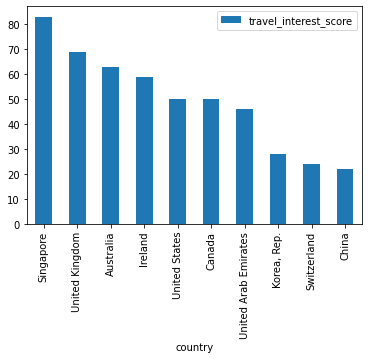

In [75]:
# quick visualization

selected_countries_gt_df.sort_values(
    "travel_interest_score",
    ascending=False
).head(10).plot.bar(
    x="country",
    y="travel_interest_score"
)

---
## Notebook 3 — Summary

| Output | Description |
|---|---|
| `google_trends_raw_20260620.csv` | Raw GT data — all 5 candidate keywords, all countries |
| `google_trends_long_20260620.csv` | Reshaped long format with all keywords |
| `google_trends_travel_corrected_20260620.csv` | Final travel keyword dataset — all countries |
| `selected_countries_gt_travel_scores_2024.csv` | Final merged dataset — 30 countries with travel interest scores |

**Next step:** Notebook 4 — Market Attractiveness Analysis & Business Recommendation